# Random Forest — Clasificación de Gravedad en Accidentes de Tránsito

**Dataset:** Incidentes viales municipio de Envigado · 500 registros · 32 columnas  
**Variable respuesta:** Gravedad -> Herido (0) / Muerto (1)  
**Selección de hiperparámetros:** OOB Grid Search -> CV Grid Search → Evaluación final  
**Balanceo:** Previamente, se realiza un ajuste al dataset, lo que aumenta la proporción de los 'Muertos' (1), al 26%.

---

Ahora, se realiza el segundo modelo de Random Forest, el cual se aplica al dataset de los 500 registros aleatorizado. Como observaciones iniciales, no se practican métodos de balanceo, ya que éste se "aplica" previamente al dataset, pues se logra aumentar la proporción de 'Muertos' con respecto a los 'Heridos'.

## 1. Librerías y configuración

In [29]:
# Tratamiento de datos
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

# Preprocesado
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, ParameterGrid
from sklearn.utils import resample

# Balanceo (alternativa — ver nota en introducción)
from imblearn.over_sampling import SMOTE

# Modelado
from sklearn.ensemble import RandomForestClassifier

# Evaluación
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    classification_report, confusion_matrix, roc_curve
)

# Gráficos
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# OS y HTTP
# ==============================================================================
import os, sys, requests

# Rutas de salida
os.makedirs("modelos/clasificacion", exist_ok=True)
os.makedirs("modelos/scaler", exist_ok=True)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [ ]:
# Parámetros globales
# ==============================================================================

GITHUB_BASE_URL           = 'https://raw.githubusercontent.com/yorbisUdeA/udea/main/'
DATASET_FILE_NAME         = 'DataSet_Accidentes.xlsx'
UTILS_FILE_NAME           = 'funciones.py'
DATASETS_PATH             = 'datasets/'
UTILS_PATH                = 'utils/'
MODELS_PATH               = 'modelos/'
MODELS_CLASIFICACION_PATH = os.path.join(MODELS_PATH, 'clasificacion')
MODELS_SCALER_PATH        = os.path.join(MODELS_PATH, 'scaler')

github_dataset_url = os.path.join(GITHUB_BASE_URL, DATASETS_PATH, DATASET_FILE_NAME)
github_utils_url   = os.path.join(GITHUB_BASE_URL, UTILS_PATH, UTILS_FILE_NAME)
local_dataset_path = os.path.join(DATASETS_PATH, DATASET_FILE_NAME)
local_utils_path   = os.path.join(UTILS_PATH, UTILS_FILE_NAME)


In [31]:
def download_file(url, path, description):
    '''
    Descarga un archivo desde una URL y lo guarda localmente.
    Args:
        url (str), path (str), description (str)
    '''
    print(f'Descargando {description} desde: {url}')
    response = requests.get(url)
    response.raise_for_status()
    with open(path, 'wb') as f:
        f.write(response.content)
    print(f'{description} descargado exitosamente a: {path}')

In [32]:
# Crear directorios y descargar archivos
# ==============================================================================
for p in [DATASETS_PATH, UTILS_PATH, MODELS_PATH, MODELS_CLASIFICACION_PATH, MODELS_SCALER_PATH]:
    os.makedirs(p, exist_ok=True)

download_file(github_dataset_url, local_dataset_path, 'dataset')
download_file(github_utils_url,   local_utils_path,   'funciones')


Descargando dataset desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/datasets/DataSet_Accidentes.xlsx
dataset descargado exitosamente a: datasets/DataSet_Accidentes.xlsx
Descargando funciones desde: https://raw.githubusercontent.com/yorbisUdeA/udea/main/utils/funciones.py
funciones descargado exitosamente a: utils/funciones.py


In [33]:
# Funciones externas del repositorio
# ==============================================================================
sys.path.append(UTILS_PATH)
from funciones import multiple_plot, plot_roc_curve

## 2. Carga del dataset

In [ ]:
#-----------------------SE CREA EL DATAFRAME INICIAL----------------------------
df = pd.read_excel(local_dataset_path, engine='openpyxl')
print(f"Shape: {df.shape}")
df.head(3)

Shape: (9326, 32)


,Radicado,Fecha_Accidente,Hora_Accidente,Dia_Semana,Año,Mes,Clase_Vehiculo,Tipo_Servicio,Tipo_Victima,Edad,...,Objeto_Fijo,Sector_Accidente,Condicion_Climatica,Causa_Accidente,Fecha_Accidente2,Franja_Horaria,L_Edad,T_Edad,Edad_nivel,Edad_alto
0,2173901,2018-01-02,22:50:00,Martes,2018,1,Motocicleta,Particular,Motociclista,19,...,No Reportado,Comercial,Normal,Desobedecer señales,2018-01-02,Noche,2.945312,1.303430,Joven,Adulto
1,2180000,2018-01-02,20:40:00,Martes,2018,1,Bus,Publico,Pasajero,21,...,No Reportado,Residencial,Lluvia,Desobedecer señales,2018-01-02,Noche,3.044922,1.315224,Joven,Adulto
2,2180000,2018-01-02,20:40:00,Martes,2018,1,Automovil,Particular,Conductor,31,...,No Reportado,Residencial,Lluvia,Desobedecer señales,2018-01-02,Noche,3.433594,1.362143,Adulto,Joven


In [35]:
#-----------ALEATORIZACIÓN DEL DATA SET------------------------------------
df.sample(frac=1, random_state=42)

,Radicado,Fecha_Accidente,Hora_Accidente,Dia_Semana,Año,Mes,Clase_Vehiculo,Tipo_Servicio,Tipo_Victima,Edad,...,Objeto_Fijo,Sector_Accidente,Condicion_Climatica,Causa_Accidente,Fecha_Accidente2,Franja_Horaria,L_Edad,T_Edad,Edad_nivel,Edad_alto
8602,2300736,2023-08-04,18:40:00,Viernes,2023,8,Motocicleta,Particular,Motociclista,20,...,No Reportado,Residencial,Normal,Otra-Conductor,2023-08-04,Noche,2.996094,1.309461,Joven,Adulto
2478,2200194,2020-01-26,06:00:00,Domingo,2020,1,Bicicleta,Particular,Ciclista,70,...,No Reportado,Residencial,Normal,No hacer uso de señales reflectivas o luminosa...,2020-01-26,Mañana,4.250000,1.465746,Viejo,Joven
6696,2240803,2024-08-15,19:15:00,Jueves,2024,8,Motocicleta,Particular,Motociclista,17,...,No Reportado,Residencial,Normal,Desobedecer señales,2024-08-15,Noche,2.833984,1.290448,Joven,Adulto
3794,2211426,2021-07-27,08:00:00,Martes,2021,7,Motocicleta,Particular,Motociclista,28,...,No Reportado,Residencial,Normal,Superficie humeda,2021-07-27,Mañana,3.332031,1.349722,Adulto,Adulto
7578,2250163,2025-02-11,17:32:00,Martes,2025,2,Motocicleta,Particular,Motociclista,49,...,No Reportado,Industrial,Normal,Otra-Conductor,2025-02-11,Tarde,3.892578,1.419442,Viejo,Joven
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,2240104,2024-02-04,16:56:00,Domingo,2024,2,Motocicleta,Particular,Acompañante,47,...,Otro Tipo,Residencial,Normal,Impericia en el manejo,2024-02-04,Tarde,3.849609,1.414128,Viejo,Joven
5191,2222267,2022-09-26,14:45:00,Lunes,2022,9,Motocicleta,Particular,Motociclista,23,...,No Reportado,Residencial,Normal,Desobedecer señales,2022-09-26,Tarde,3.134766,1.326037,Joven,Adulto
5390,2222500,2022-11-12,18:35:00,Sábado,2022,11,Motocicleta,Particular,Motociclista,22,...,No Reportado,Residencial,Normal,Desobedecer señales,2022-11-12,Noche,3.091797,1.320742,Joven,Adulto
860,2182556,2018-09-19,19:40:00,Miércoles,2018,9,Bicicleta,Particular,Ciclista,25,...,No Reportado,Residencial,Normal,Adelantar por la derecha,2018-09-19,Noche,3.218750,1.336025,Joven,Adulto


In [36]:
# Información inicial del data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9326 entries, 0 to 9325
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Radicado              9326 non-null   int64         
 1   Fecha_Accidente       9326 non-null   datetime64[us]
 2   Hora_Accidente        9326 non-null   str           
 3   Dia_Semana            9326 non-null   str           
 4   Año                   9326 non-null   int64         
 5   Mes                   9326 non-null   int64         
 6   Clase_Vehiculo        9326 non-null   str           
 7   Tipo_Servicio         9326 non-null   str           
 8   Tipo_Victima          9326 non-null   str           
 9   Edad                  9326 non-null   int64         
 10  Genero                9326 non-null   str           
 11  Gravedad              9326 non-null   str           
 12  Estado_Embriaguez     9326 non-null   str           
 13  Consumo_Droga         9326 no

## 3. Análisis exploratorio (EDA)

In [ ]:
# ---------------------------Distribución de la variable respuesta
print("── Distribución de Gravedad ──")
print(df["Gravedad"].value_counts())
print(f"\nProporción muertos: {(df['Gravedad']=='Muertos').mean()*100:.2f}%")
print(f"Ratio desbalance : 1 muerto por cada {(df['Gravedad']=='Heridos').sum() // (df['Gravedad']=='Muertos').sum()} heridos")

── Distribución de Gravedad ──
Gravedad
Heridos    9196
Muertos     130
Name: count, dtype: int64

Proporción muertos: 1.39%
Ratio desbalance : 1 muerto por cada 70 heridos


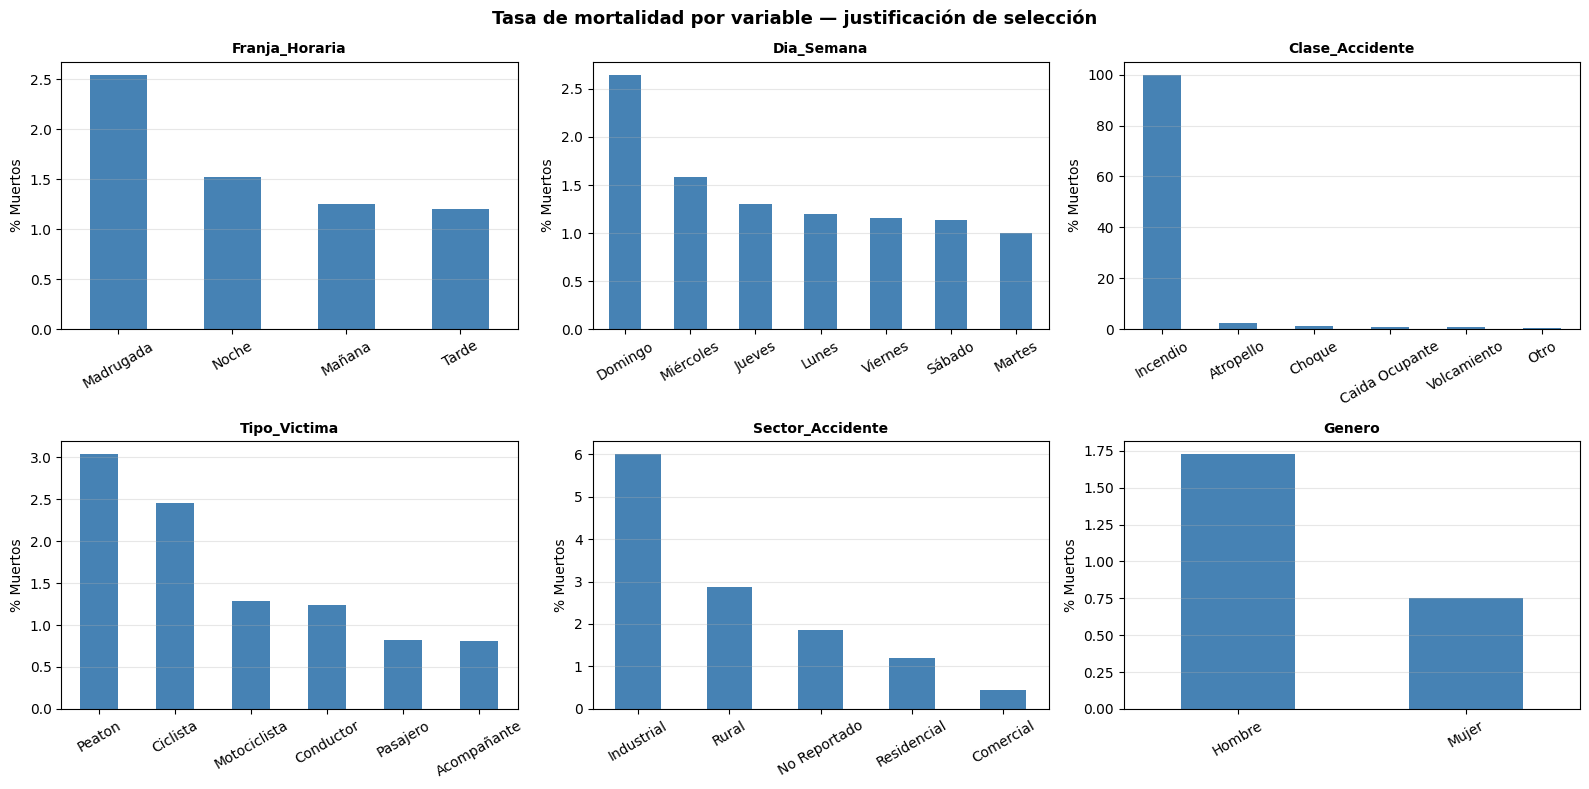

In [ ]:
# --------------------Tasa de mortalidad por variable clave
df["Gravedad_bin"] = (df["Gravedad"] == "Muertos").astype(int)

vars_eda = ["Franja_Horaria","Dia_Semana","Clase_Accidente",
            "Tipo_Victima","Sector_Accidente","Genero"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Tasa de mortalidad por variable — justificación de selección",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes.flatten(), vars_eda):
    g = df.groupby(col)["Gravedad_bin"].mean().sort_values(ascending=False) * 100
    g.plot(kind="bar", ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("% Muertos")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Preprocesamiento y selección de variables

**Por qué Label Encoding y no One-Hot Encoding:**  
Random Forest divide los datos con preguntas binarias (`variable <= umbral`)
y NO interpreta los enteros como magnitudes. Con 372 categorías en `Causa_Accidente`,
OHE generaría ~466 columnas adicionales innecesarias.
Label Encoding mantiene el dataset en 14 columnas — limpio y eficiente.

In [ ]:
# -------------------------Variable respuesta: Muertos=1, Heridos=0
df["Gravedad_bin"] = (df["Gravedad"] == "Muertos").astype(int)

# ------------------Transformación de Hora_num: extraer hora entera de string "HH:MM:SS"
df["Hora_num"] = pd.to_numeric(
    df["Hora_Accidente"].str.split(":").str[0], errors="coerce"
).fillna(14)  # 14h = mediana

# ------------------------------Variables seleccionadas (14) — justificadas por EDA
FEATURES = [
    "Franja_Horaria",     
    "Dia_Semana",         
    "Hora_num",           
    "Clase_Accidente",    
    "Clase_Vehiculo",     
    "Tipo_Victima",       
    "Sector_Accidente",   
    "Localidad_Comuna",   
    "Genero",            
    "Edad",               
    "Edad_nivel",         
    "Causa_Accidente",    
    "Condicion_Climatica",
    "Tipo_Servicio",      
]
TARGET = "Gravedad_bin"

# ---------------------------Label Encoding de variables categóricas
df_model = df[FEATURES + [TARGET]].copy()
encoders = {}
cat_cols = [c for c in FEATURES if df_model[c].dtype not in ["int64","float64"]]

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

X = df_model[FEATURES]
y = df_model[TARGET]

assert X.isnull().sum().sum() == 0, "ERROR: nulos detectados"
print(f"X shape: {X.shape} | Tasa positivos: {y.mean()*100:.2f}%")
print("✅ Preprocesamiento completo — sin nulos")

X shape: (9326, 14) | Tasa positivos: 1.39%
✅ Preprocesamiento completo — sin nulos


Entendiendo la lógica de decisión del modelo Random Forest, y cómo éste no realmente está midiendo distancias, para éste segundo modelo de Random Forest, también se establece una categorización de variables a través de Label Encoding. 

## 5. División Train / Test estratificada


In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.20,    # 20% evaluación final — 26 muertos en test
    random_state=42,   # Reproducibilidad
    stratify=y         
)

print(f"Train: {X_tr.shape[0]} | Muertos: {y_tr.sum()} ({y_tr.mean()*100:.2f}%)")
print(f"Test : {X_te.shape[0]} | Muertos: {y_te.sum()} ({y_te.mean()*100:.2f}%)")
print("✅ Estratificación correcta — proporciones idénticas")

Train: 7460 | Muertos: 104 (1.39%)
Test : 1866 | Muertos: 26 (1.39%)
✅ Estratificación correcta — proporciones idénticas


## 6. Grid Search basado en Out-of-Bag Score

**Ventaja del OOB:** cada árbol evalúa el ~36.8% de registros que no vio
durante su entrenamiento (bootstrap). Esto da validación interna **sin costo adicional**.

**Limitación:** el OOB se calcula sobre el train balanceado (con duplicados),
lo que infla levemente las métricas. Sirve para descartar combinaciones malas
y orientar el CV Grid Search, no como estimación final.

**Métrica:** `AUC-ROC` calculado sobre `oob_decision_function_`
(más informativa que `oob_score_` / accuracy con clases desbalanceadas).

In [ ]:
# -------------------Grilla de hiperparámetros para búsqueda OOB
param_grid_oob = ParameterGrid({
    "n_estimators"     : [200, 300],
    "max_depth"        : [8, 12],       
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf" : [3, 5, 10],
    "max_features"     : ["sqrt"],      
})

resultados_oob = []

for params in param_grid_oob:
    rf = RandomForestClassifier(
        **params,
        oob_score=True,          # Activa el cálculo OOB durante el fit
        bootstrap=True,          # Obligatorio para OOB
        class_weight="balanced", # Penalizar más errores en Muertos
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr, y_tr)

    # oob_decision_function_[:, 1] = P(Muerto) estimada por árboles OOB
    oob_probs = rf.oob_decision_function_[:, 1]
    mask = ~np.isnan(oob_probs)  # registros con al menos 1 árbol OOB

    oob_auc  = roc_auc_score(np.array(y_tr)[mask], oob_probs[mask])
    oob_aucpr = average_precision_score(np.array(y_tr)[mask], oob_probs[mask])

    resultados_oob.append({
        **params,
        "oob_auc"  : oob_auc,
        "oob_aucpr": oob_aucpr,
        "oob_acc"  : rf.oob_score_,  # accuracy OOB (referencia)
    })

oob_df = pd.DataFrame(resultados_oob).sort_values("oob_auc", ascending=False)
print(f"Combinaciones evaluadas: {len(oob_df)}")
oob_df.head(10)

Combinaciones evaluadas: 36


,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,oob_auc,oob_aucpr,oob_acc
30,12,sqrt,10,5,200,0.689814,0.055591,0.979759
32,12,sqrt,10,10,200,0.689814,0.055591,0.979759
34,12,sqrt,10,20,200,0.689814,0.055591,0.979759
31,12,sqrt,10,5,300,0.686782,0.055692,0.979759
33,12,sqrt,10,10,300,0.686782,0.055692,0.979759
35,12,sqrt,10,20,300,0.686782,0.055692,0.979759
28,12,sqrt,5,20,200,0.684328,0.058378,0.981367
29,12,sqrt,5,20,300,0.679180,0.057512,0.982574
14,8,sqrt,10,10,200,0.663846,0.048841,0.969839
16,8,sqrt,10,20,200,0.663846,0.048841,0.969839


In [ ]:
# Efecto de max_depth — el hiperparámetro más determinante en OOB GS
print("Efecto de max_depth en OOB AUC")
print(oob_df.groupby("max_depth")["oob_auc"].agg(["mean","max","min"]).round(4))

# Columnas de hiperparámetros (definidas explícitamente — ParameterGrid.param_grid es lista)
param_cols_oob = ["n_estimators", "max_depth", "min_samples_split",
                  "min_samples_leaf", "max_features"]

# Mejor combinación OOB
best_oob = oob_df.iloc[0]
print(f"\n Mejor OOB: {best_oob[param_cols_oob].to_dict()}")
print(f"  OOB AUC-ROC : {best_oob['oob_auc']:.4f}")
print(f"  OOB AUC-PR  : {best_oob['oob_aucpr']:.4f}")
print(f"  OOB Accuracy: {best_oob['oob_acc']:.4f}  (inflado por oversampling)")

# max_depth óptimo identificado → fijarlo para CV Grid Search
BEST_DEPTH_OOB = int(best_oob["max_depth"])
print(f"\nmax_depth={BEST_DEPTH_OOB} se fija para el CV Grid Search")

── Efecto de max_depth en OOB AUC ──
             mean     max     min
max_depth                        
8          0.6575  0.6638  0.6438
12         0.6660  0.6898  0.6439

★ Mejor OOB: {'n_estimators': 200, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
  OOB AUC-ROC : 0.6898
  OOB AUC-PR  : 0.0556
  OOB Accuracy: 0.9798  (inflado por oversampling)

→ max_depth=12 se fija para el CV Grid Search


## 7. Grid Search con Cross-Validation

In [44]:
# Grilla CV — max_depth fijado por hallazgo OOB
from itertools import product as iterproduct

param_grid_cv = {
    "n_estimators"     : [200, 300],
    "max_depth"        : [BEST_DEPTH_OOB],  # fijado por OOB GS
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf" : [3, 5, 10],
    "max_features"     : ["sqrt"],
}
combos_cv = [dict(zip(param_grid_cv, v))
             for v in iterproduct(*param_grid_cv.values())]
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

print(f"Combinaciones: {len(combos_cv)} | Folds: {K} | Entrenamientos: {len(combos_cv)*K}")
print("Métrica: AUC-ROC media sobre K folds\n")

resultados_cv = []

for params in combos_cv:
    fold_aucs, fold_prs = [], []

    for tr_idx, val_idx in skf.split(X_tr, y_tr):
        Xf_tr  = X_tr.iloc[tr_idx];  Xf_val = X_tr.iloc[val_idx]
        yf_tr  = y_tr.iloc[tr_idx];  yf_val = y_tr.iloc[val_idx]

        # Oversampling 1:5 SOLO sobre el train interno del fold
        fold_df  = pd.concat([Xf_tr, yf_tr], axis=1)
        may_f    = fold_df[fold_df[TARGET] == 0]
        mino_f   = fold_df[fold_df[TARGET] == 1]
        mino_up  = resample(mino_f, replace=True,
                            n_samples=len(may_f)//5, random_state=42)
        fold_bal = pd.concat([may_f, mino_up]).sample(
                       frac=1, random_state=42).reset_index(drop=True)

        rf = RandomForestClassifier(
            **params, class_weight="balanced",
            random_state=42, n_jobs=-1
        )
        rf.fit(fold_bal[FEATURES], fold_bal[TARGET])
        yp = rf.predict_proba(Xf_val)[:, 1]

        fold_aucs.append(roc_auc_score(yf_val, yp))
        fold_prs.append(average_precision_score(yf_val, yp))

    resultados_cv.append({
        **params,
        "cv_auc_mean": np.mean(fold_aucs),
        "cv_auc_std" : np.std(fold_aucs),
        "cv_pr_mean" : np.mean(fold_prs),
        "fold_aucs"  : fold_aucs,
    })

cv_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != "fold_aucs"}
    for r in resultados_cv
]).sort_values("cv_auc_mean", ascending=False)

print("\n── Ranking CV Grid Search ──")
print(cv_df[["n_estimators","max_depth","min_samples_split",
             "min_samples_leaf","cv_auc_mean","cv_auc_std","cv_pr_mean"]].to_string(index=False))

Combinaciones: 18 | Folds: 5 | Entrenamientos: 90
Métrica: AUC-ROC media sobre K folds


── Ranking CV Grid Search ──
 n_estimators  max_depth  min_samples_split  min_samples_leaf  cv_auc_mean  cv_auc_std  cv_pr_mean
          300         12                 20                10     0.645078    0.021655    0.086828
          300         12                 10                10     0.645078    0.021655    0.086828
          300         12                  5                10     0.645078    0.021655    0.086828
          200         12                 10                10     0.644606    0.018915    0.084548
          200         12                 20                10     0.644606    0.018915    0.084548
          200         12                  5                10     0.644606    0.018915    0.084548
          200         12                 20                 3     0.634542    0.028398    0.090174
          300         12                 20                 3     0.634511    0.023946    

In [ ]:
# ------------Análisis del hiperparámetro más determinante
print("── Efecto de min_samples_leaf en CV AUC-ROC ──")
print(cv_df.groupby("min_samples_leaf")["cv_auc_mean"].agg(["mean","max"]).round(4))

# ---------------------Mejor combinación CV
best_cv_row = cv_df.iloc[0]
BEST_PARAMS = {
    "n_estimators"     : int(best_cv_row["n_estimators"]),
    "max_depth"        : int(best_cv_row["max_depth"]),
    "min_samples_split": int(best_cv_row["min_samples_split"]),
    "min_samples_leaf" : int(best_cv_row["min_samples_leaf"]),
    "max_features"     : best_cv_row["max_features"],
}
print(f"\nMejores parámetros CV: {BEST_PARAMS}")
print(f"  CV AUC-ROC: {best_cv_row['cv_auc_mean']:.4f} ± {best_cv_row['cv_auc_std']:.4f}")
print(f"  CV AUC-PR : {best_cv_row['cv_pr_mean']:.4f}")

── Efecto de min_samples_leaf en CV AUC-ROC ──
                    mean     max
min_samples_leaf                
3                 0.6265  0.6345
5                 0.6311  0.6344
10                0.6448  0.6451

★ Mejores parámetros CV: {'n_estimators': 300, 'max_depth': 12, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt'}
  CV AUC-ROC: 0.6451 ± 0.0217
  CV AUC-PR : 0.0868


## 9. Modelo final y evaluación en Test

Se reentrena con **todo el train** usando los mejores parámetros del CV GS.
El test se usa por **primera y única vez** aquí.

In [ ]:
#-----------------------------Entrenamiento final con todos los datos de train
modelo_final = RandomForestClassifier(
    **BEST_PARAMS,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
modelo_final.fit(X_tr, y_tr)

# Umbral óptimo: maximiza F1 de la clase Muertos sobre el train
y_prob_tr = modelo_final.predict_proba(X_tr)[:, 1]
best_f1, UMBRAL = 0, 0.50
for t in np.arange(0.05, 0.70, 0.01):
    f1 = f1_score(y_tr, (y_prob_tr>=t).astype(int),
                  pos_label=1, zero_division=0)
    if f1 > best_f1: best_f1, UMBRAL = f1, t

print(f"Umbral óptimo: {UMBRAL:.2f}  (F1 train={best_f1:.4f})")

# ── EVALUACIÓN FINAL EN TEST ─────────────────────────────────────────────
y_prob_te = modelo_final.predict_proba(X_te)[:, 1]
y_pred_te = (y_prob_te >= UMBRAL).astype(int)
cm = confusion_matrix(y_te, y_pred_te)

print(f"\n── Métricas Test ──")
print(f"AUC-ROC  : {roc_auc_score(y_te, y_prob_te):.4f}")
print(f"AUC-PR   : {average_precision_score(y_te, y_prob_te):.4f}  (baseline={y_te.mean():.4f})")
print(f"F1-Muerto: {f1_score(y_te, y_pred_te, pos_label=1, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_te, y_pred_te, pos_label=1, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_te, y_pred_te, pos_label=1, zero_division=0):.4f}")
print(f"\n{classification_report(y_te, y_pred_te, target_names=['Herido','Muerto'])}")

Umbral óptimo: 0.51  (F1 train=0.7848)

── Métricas Test ──
AUC-ROC  : 0.7120
AUC-PR   : 0.0335  (baseline=0.0139)
F1-Muerto: 0.0571
Recall   : 0.0385
Precision: 0.1111

              precision    recall  f1-score   support

      Herido       0.99      1.00      0.99      1840
      Muerto       0.11      0.04      0.06        26

    accuracy                           0.98      1866
   macro avg       0.55      0.52      0.52      1866
weighted avg       0.97      0.98      0.98      1866



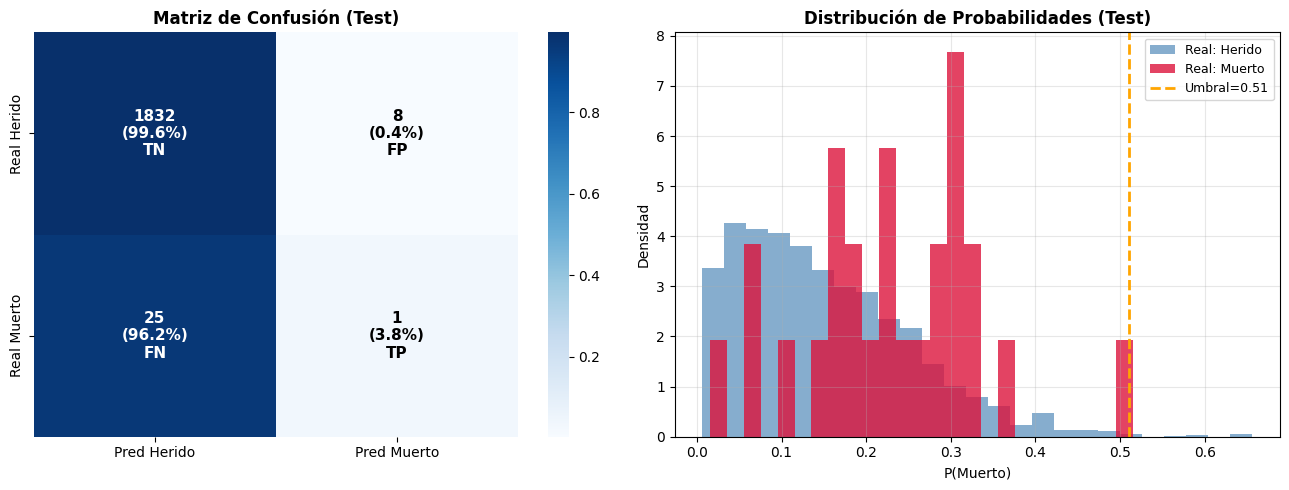

In [ ]:
#---------------------Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Heatmap ──
norm_cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(norm_cm, annot=False, cmap="Blues", ax=axes[0])
for i in range(2):
    for j in range(2):
        etiq = ["TN","FP","FN","TP"][i*2+j]
        axes[0].text(j+0.5, i+0.5,
            f"{cm[i,j]}\n({norm_cm[i,j]:.1%})\n{etiq}",
            ha="center", va="center", fontsize=11, fontweight="bold",
            color="white" if norm_cm[i,j]>0.5 else "black")
axes[0].set_xticklabels(["Pred Herido","Pred Muerto"])
axes[0].set_yticklabels(["Real Herido","Real Muerto"])
axes[0].set_title("Matriz de Confusión (Test)", fontweight="bold")

# ── Distribución de probabilidades ──
y_te_arr = np.array(y_te)
axes[1].hist(y_prob_te[y_te_arr==0], bins=25, alpha=0.65,
             color="steelblue", label="Real: Herido", density=True)
axes[1].hist(y_prob_te[y_te_arr==1], bins=25, alpha=0.80,
             color="crimson", label="Real: Muerto", density=True)
axes[1].axvline(x=UMBRAL, color="orange", lw=2, linestyle="--",
                label=f"Umbral={UMBRAL:.2f}")
axes[1].set_xlabel("P(Muerto)")
axes[1].set_ylabel("Densidad")
axes[1].set_title("Distribución de Probabilidades (Test)", fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Gráfico ROC-CURVA

In [48]:
# Curva ROC
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_te, y_prob_tr)
auc = roc_auc_score(y_te, y_prob_tr)

fig, ax = plt.subplots(figsize=(7, 5))

# Curva ROC del modelo
ax.plot(fpr, tpr, color='#E84C4C', linewidth=2.5,
        label=f'Modelo Regresión Logística (AUC = {auc:.4f})')

# Línea de referencia (clasificador aleatorio)
ax.plot([0, 1], [0, 1], color='navy', linewidth=1.5,
        linestyle='--', label='Clasificador Aleatorio (AUC = 0.50)')

# Marcar el punto de corte óptimo (máxima distancia a la diagonal)
optimal_idx = np.argmax(tpr - fpr)
ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
           marker='o', color='#E84C4C', s=80, zorder=5,
           label=f'Umbral óptimo = {thresholds[optimal_idx]:.2f}')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC – Predicción de Gravedad de Accidentes', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f'AUC-ROC : {auc:.4f}')
print(f'Umbral óptimo (Youden): {thresholds[optimal_idx]:.4f}')
print(f'  → TPR en umbral óptimo: {tpr[optimal_idx]:.4f}')
print(f'  → FPR en umbral óptimo: {fpr[optimal_idx]:.4f}')

ValueError: Found input variables with inconsistent numbers of samples: [1866, 7460]

## 11. Importancia de variables

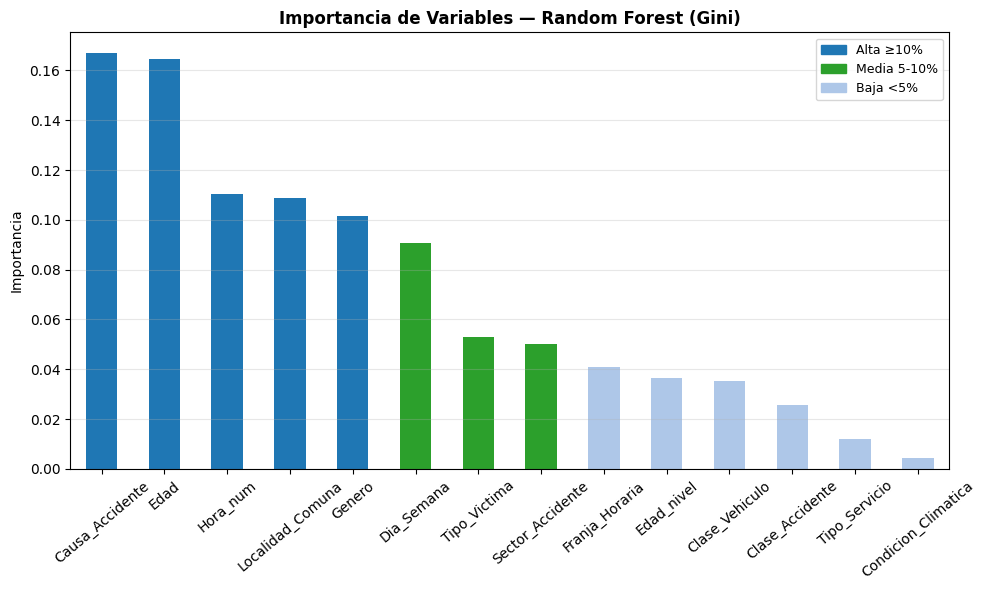


Top 5 variables:
  Causa_Accidente           0.1669  ██████████████████████████████████████████████████
  Edad                      0.1644  █████████████████████████████████████████████████
  Hora_num                  0.1102  █████████████████████████████████
  Localidad_Comuna          0.1088  ████████████████████████████████
  Genero                    0.1015  ██████████████████████████████


In [ ]:
importancia = pd.Series(
    modelo_final.feature_importances_, index=FEATURES
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#1f77b4" if v>=0.10 else "#ef0000" if v>=0.05
          else "#aec7e8" for v in importancia.values]
importancia.plot(kind="bar", ax=ax, color=colors, edgecolor="none")
ax.set_title("Importancia de Variables — Random Forest (Gini)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Importancia")
ax.tick_params(axis="x", rotation=40)
ax.grid(axis="y", alpha=0.3)

p1 = mpatches.Patch(color="#1f77b4", label="Alta ≥10%")
p2 = mpatches.Patch(color="#2ca02c", label="Media 5-10%")
p3 = mpatches.Patch(color="#aec7e8", label="Baja <5%")
ax.legend(handles=[p1,p2,p3], fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 5 variables:")
for feat, val in importancia.head(5).items():
    print(f"  {feat:<25} {val:.4f}  {'█'*int(val*300)}")

## 12. Guardar modelo y función de predicción

In [ ]:
# ---------------------------Guardar modelo-----------------------------
artifacts = {
    "modelo"      : modelo_final,
    "encoders"    : encoders,
    "features"    : FEATURES,
    "target"      : TARGET,
    "umbral"      : UMBRAL,
    "best_params" : BEST_PARAMS,
    "importancia" : importancia,
}

joblib.dump(artifacts, os.path.join(MODELS_CLASIFICACION_PATH, 'RandomForest_Accidentes_500.pkl'))
print('Modelo entrenado y guardado.')

Modelo guardado en: C:\\Users\\Santiago\\Desktop\\Esp\\venv\\RF5_Gravedad_Accidente_500.pkl


In [ ]:
def predecir_gravedad(nuevo_accidente: dict,
                      path: str = "C:\\Users\\Santiago\\Desktop\\Esp\\venv\\RF3_Gravedad_Accidente.pkl") -> dict:
    """
    Predice la probabilidad de mortalidad para un nuevo accidente.

    Parámetros
    ----------
    nuevo_accidente : dict con las 14 variables del modelo
        Ejemplo:
        {
            "Franja_Horaria"     : "Madrugada",
            "Dia_Semana"         : "Domingo",
            "Hora_num"           : 2,
            "Clase_Accidente"    : "Atropello",
            "Clase_Vehiculo"     : "Motocicleta",
            "Tipo_Victima"       : "Peaton",
            "Sector_Accidente"   : "Rural",
            "Localidad_Comuna"   : "El Escobero",
            "Genero"             : "Hombre",
            "Edad"               : 55,
            "Edad_nivel"         : "Viejo",
            "Causa_Accidente"    : "Impericia en el manejo",
            "Condicion_Climatica": "Normal",
            "Tipo_Servicio"      : "Particular",
        }
    """
    import joblib, pandas as pd
    art = joblib.load(path)
    row = {}
    for feat in art["features"]:
        val = nuevo_accidente.get(feat)
        if feat in art["encoders"]:
            enc = art["encoders"][feat]
            vs  = str(val)
            row[feat] = enc.transform([vs])[0] if vs in enc.classes_ else -1
        else:
            row[feat] = float(val)
    X_new = pd.DataFrame([row])[art["features"]]
    prob  = art["modelo"].predict_proba(X_new)[0, 1]
    pred  = int(prob >= art["umbral"])
    nivel = "ALTO" if prob >= 0.70 else "MEDIO" if prob >= 0.40 else "BAJO"
    return {
        "probabilidad_muerte": round(float(prob), 4),
        "prediccion"         : "Muerto" if pred else "Herido",
        "nivel_riesgo"       : nivel,
        "umbral_usado"       : round(art["umbral"], 2),
    }


# ── Ejemplos de predicción ────────────────────────────────────────────────
casos = {
    "Alto riesgo": {
        "Franja_Horaria":"Madrugada","Dia_Semana":"Domingo","Hora_num":2,
        "Clase_Accidente":"Atropello","Clase_Vehiculo":"Motocicleta",
        "Tipo_Victima":"Peaton","Sector_Accidente":"Rural",
        "Localidad_Comuna":"El Escobero","Genero":"Hombre","Edad":55,
        "Edad_nivel":"Viejo","Causa_Accidente":"Impericia en el manejo",
        "Condicion_Climatica":"Normal","Tipo_Servicio":"Particular",
    },
    "Bajo riesgo": {
        "Franja_Horaria":"Tarde","Dia_Semana":"Martes","Hora_num":14,
        "Clase_Accidente":"Caida Ocupante","Clase_Vehiculo":"Motocicleta",
        "Tipo_Victima":"Acompañante","Sector_Accidente":"Comercial",
        "Localidad_Comuna":"El Centro","Genero":"Mujer","Edad":25,
        "Edad_nivel":"Joven","Causa_Accidente":"Desobedecer señales",
        "Condicion_Climatica":"Normal","Tipo_Servicio":"Particular",
    },
}
for nombre, caso in casos.items():
    r = predecir_gravedad(caso)
    print(f"\n{nombre}:")
    print(f"  P(Muerto)    : {r['probabilidad_muerte']:.4f} ({r['probabilidad_muerte']*100:.2f}%)")
    print(f"  Predicción   : {r['prediccion']}")
    print(f"  Nivel riesgo : {r['nivel_riesgo']}")


Alto riesgo:
  P(Muerto)    : 0.5000 (50.00%)
  Predicción   : Herido
  Nivel riesgo : MEDIO

Bajo riesgo:
  P(Muerto)    : 0.0257 (2.57%)
  Predicción   : Herido
  Nivel riesgo : BAJO


## 13. Referencias

- Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32.
- Chawla, N. V. et al. (2002). SMOTE: Synthetic Minority Oversampling Technique.
  *JAIR*, 16, 321–357. — [Por qué no usamos SMOTE con n<200]
- scikit-learn: [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- Ciencia de datos con Python: https://www.cienciadedatos.net/documentos/py08_random_forest_python.html
- Quantdare — Gini vs Entropy: https://quantdare.com/decision-trees-gini-vs-entropy/